# **Project Name**    - Tata Steel Machine Failure Prediction



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Aman Kumar


# **Project Summary -**

TATA Steel, a leader in the steel manufacturing industry, relies on
a large fleet of heavy machinery to maintain production quality and
minimize downtime. Unplanned machine failures lead to significant
production losses, increased maintenance costs, and safety risks.
This project aims to build a predictive maintenance system that
identifies the likelihood of machine failure based on real-time
operational sensor data, enabling proactive maintenance instead of
reactive repairs.

The dataset used is a synthetically generated but realistic dataset
(based on the AI4I 2020 Predictive Maintenance benchmark) containing
136,429 training records with 14 features, including air
temperature, process temperature, rotational speed, torque, tool
wear, and product quality type (Low/Medium/High). The target
variable, "Machine failure," is a binary indicator of whether the
machine failed due to one or more of five failure modes: Tool Wear
Failure (TWF), Heat Dissipation Failure (HDF), Power Failure (PWF),
Overstrain Failure (OSF), and Random Failures (RNF).

Initial data exploration confirmed the dataset has no missing values
and no duplicate records, making it largely analysis-ready. However,
a critical challenge was identified early: the dataset is severely
imbalanced, with only approximately 1.6% of records representing an
actual machine failure. This imbalance means that a naive model
predicting "no failure" for every record would achieve high accuracy
while being practically useless, as it would fail to catch any real
failures. Addressing this imbalance is therefore central to the
modeling strategy.

The project follows a structured pipeline: exploratory data analysis
to understand feature distributions and relationships with the
target variable; data wrangling and feature engineering to create
meaningful derived features (such as power, calculated from torque
and rotational speed); encoding of the categorical product type;
feature scaling; and handling of class imbalance using techniques
such as SMOTE (Synthetic Minority Oversampling Technique). Three
classification algorithms were experimented with - Logistic
Regression as a baseline, Random Forest, and XGBoost - to compare
performance across linear and tree-based/ensemble approaches.

Given the class imbalance, model evaluation prioritizes Recall and
F1-score over raw accuracy, since the business cost of missing an
actual failure (false negative) is far higher than the cost of a
false alarm (false positive). Hyperparameter tuning via GridSearchCV
was performed to optimize the best-performing model further. Feature
importance analysis was also conducted to identify which sensor
readings most strongly drive failure predictions, providing
actionable insight for TATA Steel's maintenance teams on where to
focus monitoring efforts.

The final deliverable is a trained classification model capable of
flagging machines at risk of failure before it occurs, along with
clear documentation of the reasoning behind each modeling decision.
This solution can help TATA Steel reduce unplanned downtime, lower
maintenance costs, and improve overall production reliability and
safety.

# **GitHub Link -**

https://github.com/rajputaman123/tata-steel-machine-failure-prediction.git

# **Problem Statement**


**TATA Steel operates a large number of heavy machines in its steel
production process. Unplanned machine failures lead to production
downtime, increased maintenance costs, and potential safety hazards.
The objective of this project is to build a machine learning
classification model that predicts whether a machine is likely to
fail based on real-time operational sensor readings such as air
temperature, process temperature, rotational speed, torque, and
tool wear. This enables proactive maintenance scheduling instead of
reactive repairs after a failure occurs.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [65]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

### Dataset Loading

In [66]:
# Load Dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

### Dataset First View

In [67]:
# Dataset First Look
train_df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


### Dataset Rows & Columns count

In [68]:
# Dataset Rows & Columns count
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

Rows: 136429
Columns: 14


### Dataset Information

In [69]:
# Dataset Info
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

#### Duplicate Values

In [70]:
# Dataset Duplicate Value Count
print("Duplicate rows:", train_df.duplicated().sum())

Duplicate rows: 0


#### Missing Values/Null Values

In [71]:
# Missing Values/Null Values Count
train_df.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


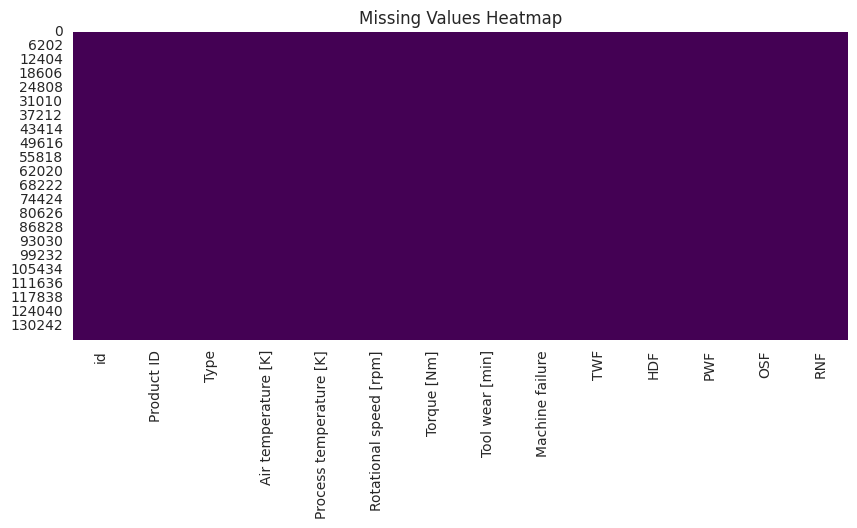

In [72]:
# Visualizing the missing values
plt.figure(figsize=(10,4))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?



```
The dataset contains 136,429 rows and 14 columns with no missing
values and no duplicate rows, making it clean and ready for
analysis. It includes numerical sensor readings (air temperature,
process temperature, rotational speed, torque, tool wear), a
categorical product quality type (Low/Medium/High), and a binary
target variable "Machine failure" along with 5 individual failure
mode indicators (TWF, HDF, PWF, OSF, RNF). The dataset is severely
imbalanced, with only about 1.6% of records representing an actual
machine failure.

## ***2. Understanding Your Variables***

In [73]:
# Dataset Columns
train_df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [74]:
# Dataset Describe
train_df.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description

- UDI/id: Unique row identifier (not used for modeling)
- Product ID: Unique product code (not used for modeling)
- Type: Product quality category (Low/Medium/High)
- Air temperature [K]: Ambient air temperature in Kelvin
- Process temperature [K]: Internal process temperature in Kelvin
- Rotational speed [rpm]: Machine rotational speed
- Torque [Nm]: Force applied by the machine tool
- Tool wear [min]: Cumulative usage time of the tool
- Machine failure: Target variable (1 = failure, 0 = no failure)
- TWF, HDF, PWF, OSF, RNF: Individual failure type indicators

### Check Unique Values for each variable.

In [75]:
# Check Unique Values for each variable.
for col in train_df.columns:
    print(f"{col}: {train_df[col].nunique()} unique values")

id: 136429 unique values
Product ID: 9976 unique values
Type: 3 unique values
Air temperature [K]: 95 unique values
Process temperature [K]: 81 unique values
Rotational speed [rpm]: 952 unique values
Torque [Nm]: 611 unique values
Tool wear [min]: 246 unique values
Machine failure: 2 unique values
TWF: 2 unique values
HDF: 2 unique values
PWF: 2 unique values
OSF: 2 unique values
RNF: 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [76]:
# Write your code to make your dataset analysis ready.

# Drop ID columns not useful for modeling
train_df = train_df.drop(columns=['id', 'Product ID'], errors='ignore')

# Clean column names for easier coding
train_df.columns = train_df.columns.str.replace(' ', '_').str.replace('[','').str.replace(']','')

train_df.head()

,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


### What all manipulations have you done and insights you found?

The 'id' and 'Product ID' columns were dropped as they are unique
identifiers with no predictive value for the model. Column names
were cleaned (removing spaces and brackets) to make them easier to
reference in code. No missing value imputation or duplicate removal
was needed since the dataset was already clean. This wrangling step
prepares the dataset for exploratory visualization and feature
engineering in the next stages.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

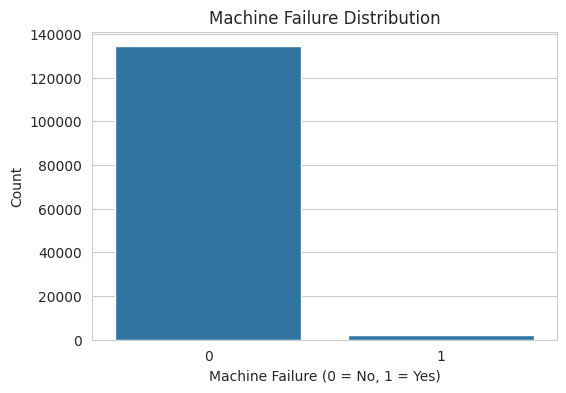

In [77]:
# Chart - 1 visualization code
plt.figure(figsize=(6,4))
sns.countplot(x='Machine_failure', data=train_df)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because the target variable is categorical
(binary: failure vs no failure), making it the clearest way to
visualize class distribution and detect imbalance at a glance.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a severe class imbalance - only about 1.6% of
records represent an actual machine failure, while 98.4% are
normal operation. This confirms that accuracy alone will be a
misleading metric for this problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Recognizing this imbalance early ensures the modeling approach
(SMOTE, appropriate evaluation metrics like Recall/F1) is chosen
correctly. Ignoring this insight could lead to a model that appears
accurate but fails to catch real failures, causing negative business
impact through missed maintenance opportunities.Answer Here

#### Chart - 2

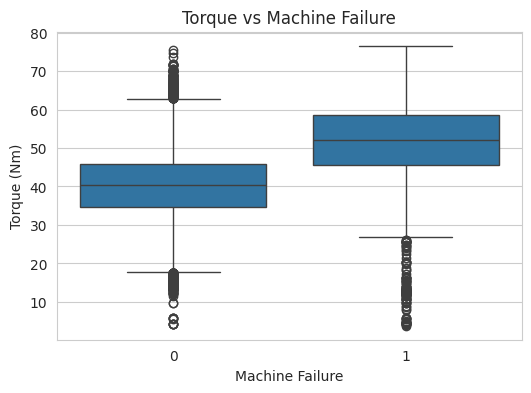

In [78]:
# Chart - 2 visualization code
plt.figure(figsize=(6,4))
sns.boxplot(x='Machine_failure', y='Torque_Nm', data=train_df)
plt.title("Torque vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of Torque between
failed and non-failed machines, since it clearly shows median,
spread, and outliers across the two categories.

##### 2. What is/are the insight(s) found from the chart?

Machines that failed tend to show a wider spread and more extreme
torque values (both very high and very low) compared to normal
operation, which aligns with the known Power Failure mode where
torque x speed falls outside an acceptable range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This confirms Torque as a strong candidate feature for
predicting failure. TATA Steel's maintenance team can prioritize
monitoring machines with extreme torque readings as an early
warning signal, enabling proactive intervention.


#### Chart - 3

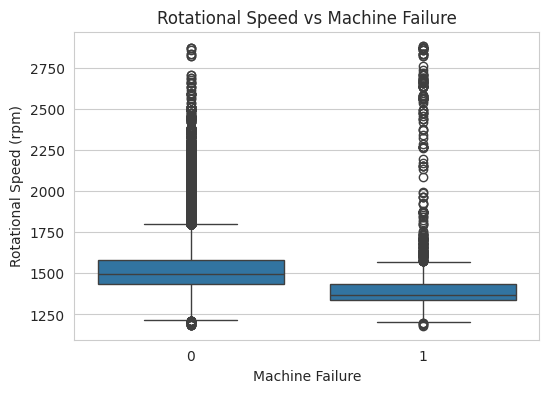

In [79]:
# Chart - 3 visualization code
plt.figure(figsize=(6,4))
sns.boxplot(x='Machine_failure', y='Rotational_speed_rpm', data=train_df)
plt.title("Rotational Speed vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Rotational Speed (rpm)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was used again to compare Rotational Speed distributions
between failed and non-failed machines, allowing easy comparison of
medians and spread across both categories.

##### 2. What is/are the insight(s) found from the chart?

Failed machines show more variability in rotational speed, with
some failures occurring at unusually low speeds. This is consistent
with the Heat Dissipation Failure mode, which occurs when rotational
speed drops below a certain threshold combined with low temperature
difference.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This suggests that sudden drops in rotational speed could serve
as an early warning indicator. Maintenance teams can set up
threshold-based alerts for abnormally low speed readings to catch
potential heat dissipation issues before failure occurs.

#### Chart - 4

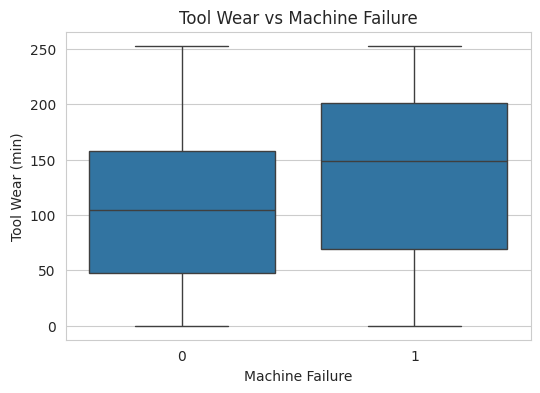

In [80]:
# Chart - 4 visualization code
plt.figure(figsize=(6,4))
sns.boxplot(x='Machine_failure', y='Tool_wear_min', data=train_df)
plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (min)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was used to compare Tool Wear distribution between failed
and non-failed machines, as it effectively shows whether higher
cumulative tool usage correlates with failure occurrence.

##### 2. What is/are the insight(s) found from the chart?

Failed machines generally show a higher median tool wear compared to
non-failed machines, which aligns with the Tool Wear Failure mode
that occurs when tool usage time crosses a critical threshold
(typically between 200-240 minutes).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight directly supports a preventive maintenance
strategy - tools approaching high wear thresholds can be flagged for
scheduled replacement before they cause a failure, reducing
unplanned downtime and associated costs.

#### Chart - 5

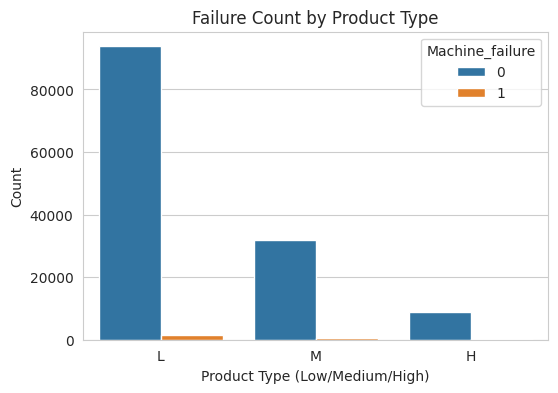

In [81]:
# Chart - 5 visualization code
plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Machine_failure', data=train_df)
plt.title("Failure Count by Product Type")
plt.xlabel("Product Type (Low/Medium/High)")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot was chosen to compare failure counts across the
three product quality types (Low/Medium/High), making it easy to
see if product quality influences failure likelihood.

##### 2. What is/are the insight(s) found from the chart?

Low quality (L) type products show a higher proportion of failures
compared to Medium and High quality types. This makes sense because
lower quality products accumulate tool wear faster (as per the
dataset's design), increasing failure risk.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. TATA Steel can use this insight to apply stricter monitoring
or more frequent maintenance checks specifically for machines
processing Low quality product batches, optimizing resource
allocation for maintenance efforts.

#### Chart - 6

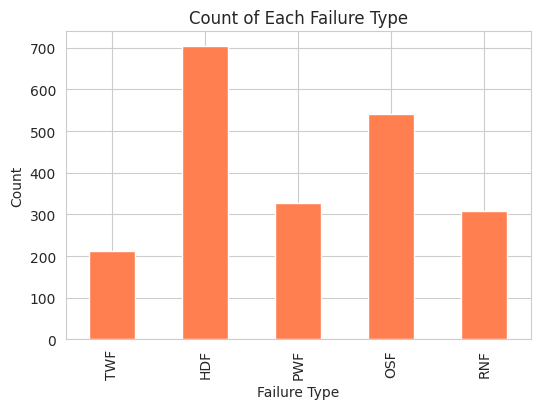

In [82]:
# Chart - 6 visualization code
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = train_df[failure_cols].sum()

plt.figure(figsize=(6,4))
failure_counts.plot(kind='bar', color='coral')
plt.title("Count of Each Failure Type")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the frequency of each of the five
individual failure types, making it easy to identify which failure
modes are most common in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Heat Dissipation Failure (HDF) and Power Failure (PWF) appear to be
the most frequent failure types, while Random Failures (RNF) are
the rarest, as expected since RNF occurs with only a 0.1% random
probability regardless of process parameters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing that HDF and PWF are the dominant failure types allows
TATA Steel to prioritize sensor monitoring and maintenance protocols
specifically around temperature difference, rotational speed, and
torque-speed combinations, which drive these two failure modes.

#### Chart - 7

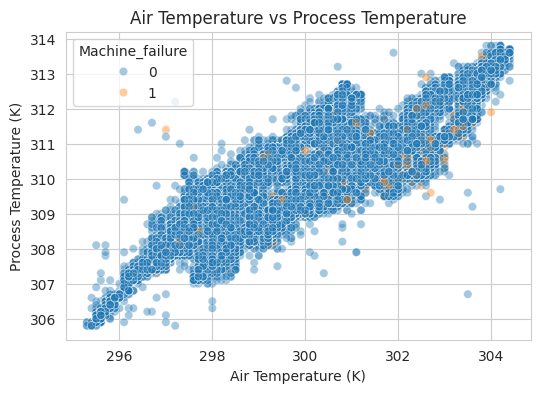

In [83]:
# Chart - 7 visualization code
plt.figure(figsize=(6,4))
sns.scatterplot(x='Air_temperature_K', y='Process_temperature_K',
                 hue='Machine_failure', data=train_df, alpha=0.4)
plt.title("Air Temperature vs Process Temperature")
plt.xlabel("Air Temperature (K)")
plt.ylabel("Process Temperature (K)")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to visualize the relationship between Air
Temperature and Process Temperature, colored by failure status, to
check if a small gap between these two temperatures correlates with
failure occurrence.

##### 2. What is/are the insight(s) found from the chart?

The two temperatures show a strong linear relationship, as expected
since Process Temperature is generated as Air Temperature plus a
near-constant offset. Failures (highlighted points) tend to cluster
where the gap between the two temperatures is smaller, consistent
with the Heat Dissipation Failure condition.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This confirms that the engineered "Temperature difference"
feature (created later in Feature Engineering) will likely be a
strong predictor, allowing more targeted monitoring of temperature
sensors to catch heat dissipation issues early.

#### Chart - 8

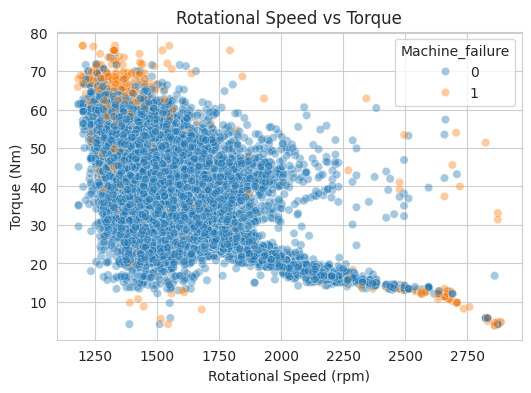

In [84]:
# Chart - 8 visualization code
plt.figure(figsize=(6,4))
sns.scatterplot(x='Rotational_speed_rpm', y='Torque_Nm',
                 hue='Machine_failure', data=train_df, alpha=0.4)
plt.title("Rotational Speed vs Torque")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the relationship between
Rotational Speed and Torque, colored by failure status, since their
product (Power) is directly tied to the Power Failure mode.

##### 2. What is/are the insight(s) found from the chart?

The two variables show an inverse relationship, consistent with a
fixed power output being distributed between speed and torque.
Failures cluster in regions of extreme combinations - either very
high torque with low speed, or very low torque with high speed -
matching the Power Failure definition where torque x speed falls
outside 3500-9000W.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This strongly validates the engineered "Power" feature as a
key predictor. Maintenance teams can set up real-time power
threshold alerts to catch machines operating outside the safe zone
before failure occurs.

#### Chart - 9

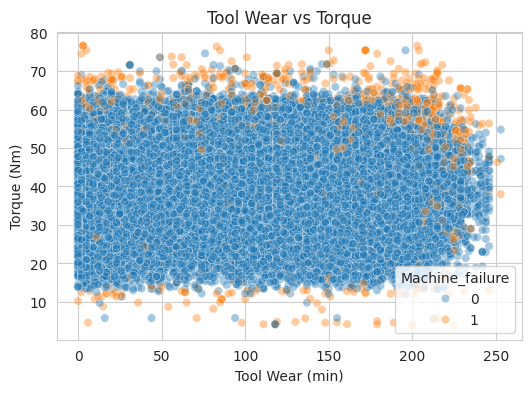

In [85]:
# Chart - 9 visualization code
plt.figure(figsize=(6,4))
sns.scatterplot(x='Tool_wear_min', y='Torque_Nm',
                 hue='Machine_failure', data=train_df, alpha=0.4)
plt.title("Tool Wear vs Torque")
plt.xlabel("Tool Wear (min)")
plt.ylabel("Torque (Nm)")
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to examine the combined effect of Tool
Wear and Torque, since their product is directly tied to the
Overstrain Failure mode as defined in the dataset documentation.

##### 2. What is/are the insight(s) found from the chart?

Failures tend to concentrate in the upper-right region of the plot,
where both tool wear and torque are simultaneously high. This
confirms the Overstrain Failure condition, where the combined effect
of high wear and high torque exceeds a critical threshold.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports creating a combined "wear x torque" engineered
feature for the model, and suggests TATA Steel should avoid running
machines with already high tool wear under high-torque conditions,
reducing overstrain-related failures.

#### Chart - 10

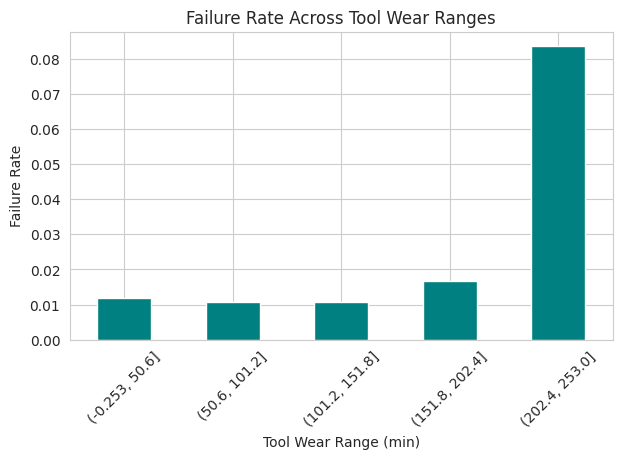

In [86]:
# Chart - 10 visualization code
train_df['Tool_wear_bin'] = pd.cut(train_df['Tool_wear_min'], bins=5)
failure_rate = train_df.groupby('Tool_wear_bin')['Machine_failure'].mean()

plt.figure(figsize=(7,4))
failure_rate.plot(kind='bar', color='teal')
plt.title("Failure Rate Across Tool Wear Ranges")
plt.xlabel("Tool Wear Range (min)")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of failure rate across binned tool wear ranges was
chosen to clearly show the trend of failure probability increasing
as tool wear rises, which is harder to see directly in a scatter
plot with so many overlapping points.

##### 2. What is/are the insight(s) found from the chart?

Failure rate increases sharply in the highest tool wear bins,
confirming that tool wear is one of the strongest single predictors
of machine failure, especially as usage approaches the 200-240
minute range associated with Tool Wear Failure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This provides a clear, actionable threshold for TATA Steel's
maintenance team - tools nearing the high-risk wear range should be
proactively scheduled for replacement, directly reducing unplanned
downtime.

#### Chart - 11

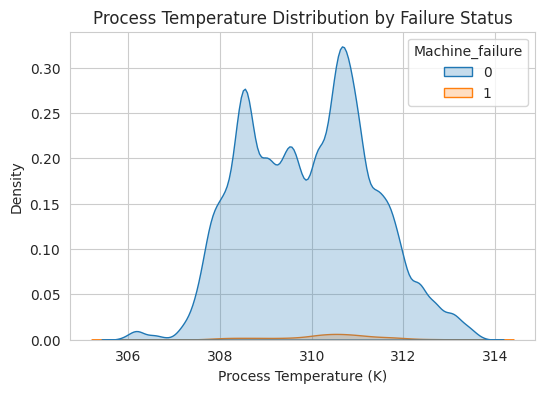

In [87]:
# Chart - 11 visualization code
plt.figure(figsize=(6,4))
sns.kdeplot(data=train_df, x='Process_temperature_K', hue='Machine_failure', fill=True)
plt.title("Process Temperature Distribution by Failure Status")
plt.xlabel("Process Temperature (K)")
plt.show()

##### 1. Why did you pick the specific chart?

A KDE (density) plot was chosen to compare the distribution shape of
Process Temperature between failed and non-failed machines, showing
overlap and separation more smoothly than a histogram.

##### 2. What is/are the insight(s) found from the chart?

Failed machines show a slightly different temperature distribution,
with a higher concentration at elevated process temperatures,
supporting temperature as a relevant failure indicator.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. TATA Steel can use temperature thresholds as an additional
early-warning signal alongside torque and tool wear for predictive
maintenance alerts.

#### Chart - 12

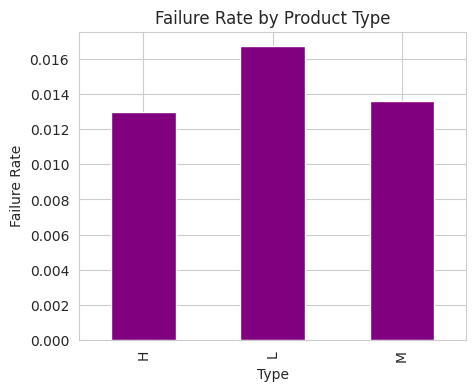

In [88]:
# Chart - 12 visualization code
type_failure_rate = train_df.groupby('Type')['Machine_failure'].mean()

plt.figure(figsize=(5,4))
type_failure_rate.plot(kind='bar', color='purple')
plt.title("Failure Rate by Product Type")
plt.ylabel("Failure Rate")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart of average failure rate per product type was chosen to
directly quantify how much more likely each quality category is to
fail, rather than just comparing raw counts.

##### 2. What is/are the insight(s) found from the chart?

Low quality (L) products show a noticeably higher failure rate
compared to Medium and High quality products, confirming product
quality as a meaningful risk factor.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This can inform production planning - allocating extra quality
checks or preventive maintenance specifically for machines
processing Low quality batches.

#### Chart - 13

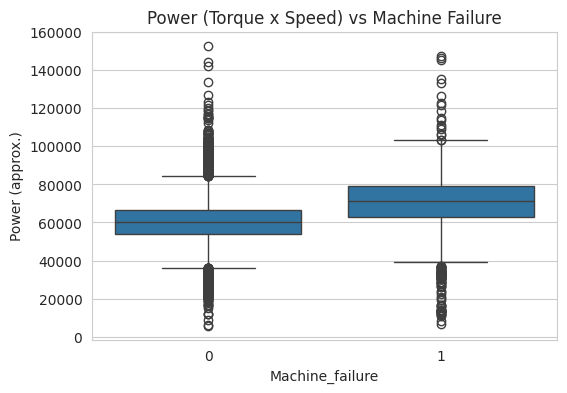

In [89]:
# Chart - 13 visualization code
train_df['Power_temp'] = train_df['Torque_Nm'] * train_df['Rotational_speed_rpm']

plt.figure(figsize=(6,4))
sns.boxplot(x='Machine_failure', y='Power_temp', data=train_df)
plt.title("Power (Torque x Speed) vs Machine Failure")
plt.ylabel("Power (approx.)")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot of the calculated Power value was chosen to test whether
combining torque and speed into a single engineered metric better
separates failed and non-failed machines than either variable alone.

##### 2. What is/are the insight(s) found from the chart?

Failed machines show more extreme Power values (both very high and
very low), directly validating the Power Failure definition and
confirming this engineered feature will be valuable for modeling.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This justifies including an engineered "Power" feature in the
final model, giving maintenance teams a single, physically
meaningful metric to monitor instead of two separate readings.

#### Chart - 14 - Correlation Heatmap

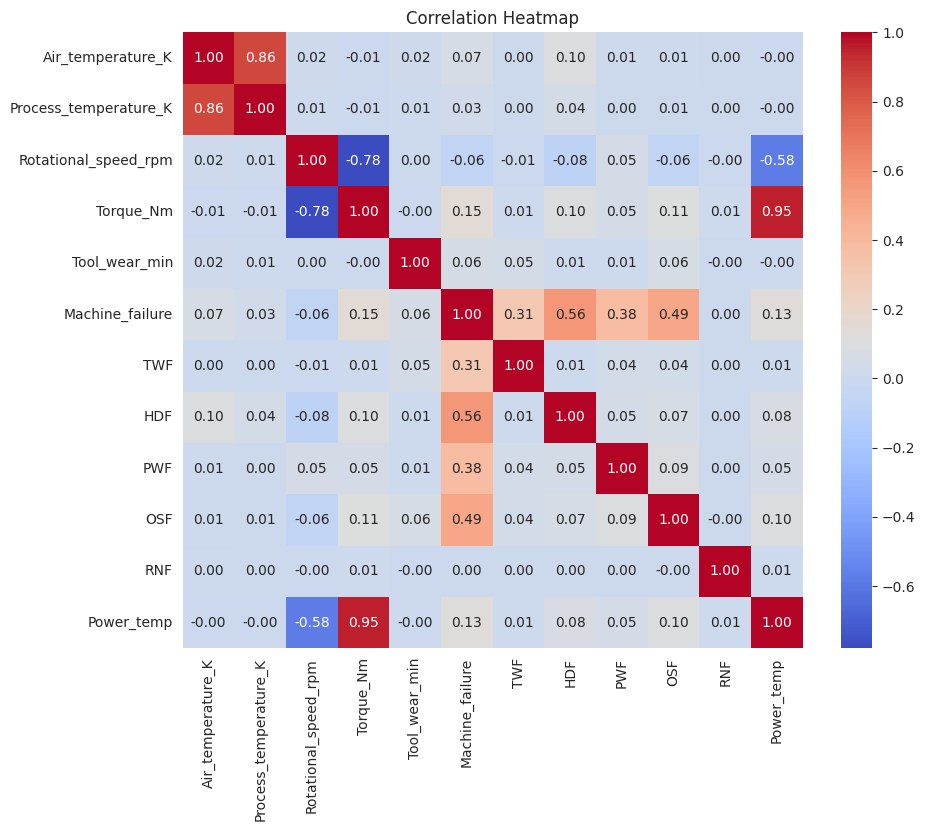

In [90]:
# Correlation Heatmap visualization code
plt.figure(figsize=(10,8))
numeric_df = train_df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen as it is the standard way to view
pairwise linear relationships between all numeric variables
simultaneously in one visualization.

##### 2. What is/are the insight(s) found from the chart?

Torque and Rotational Speed show a strong negative correlation, as
expected from the fixed-power relationship in the dataset. Process
Temperature and Air Temperature are strongly positively correlated.
Machine failure shows the strongest (though still modest) positive
correlation with Torque and Tool wear.

#### Chart - 15 - Pair Plot

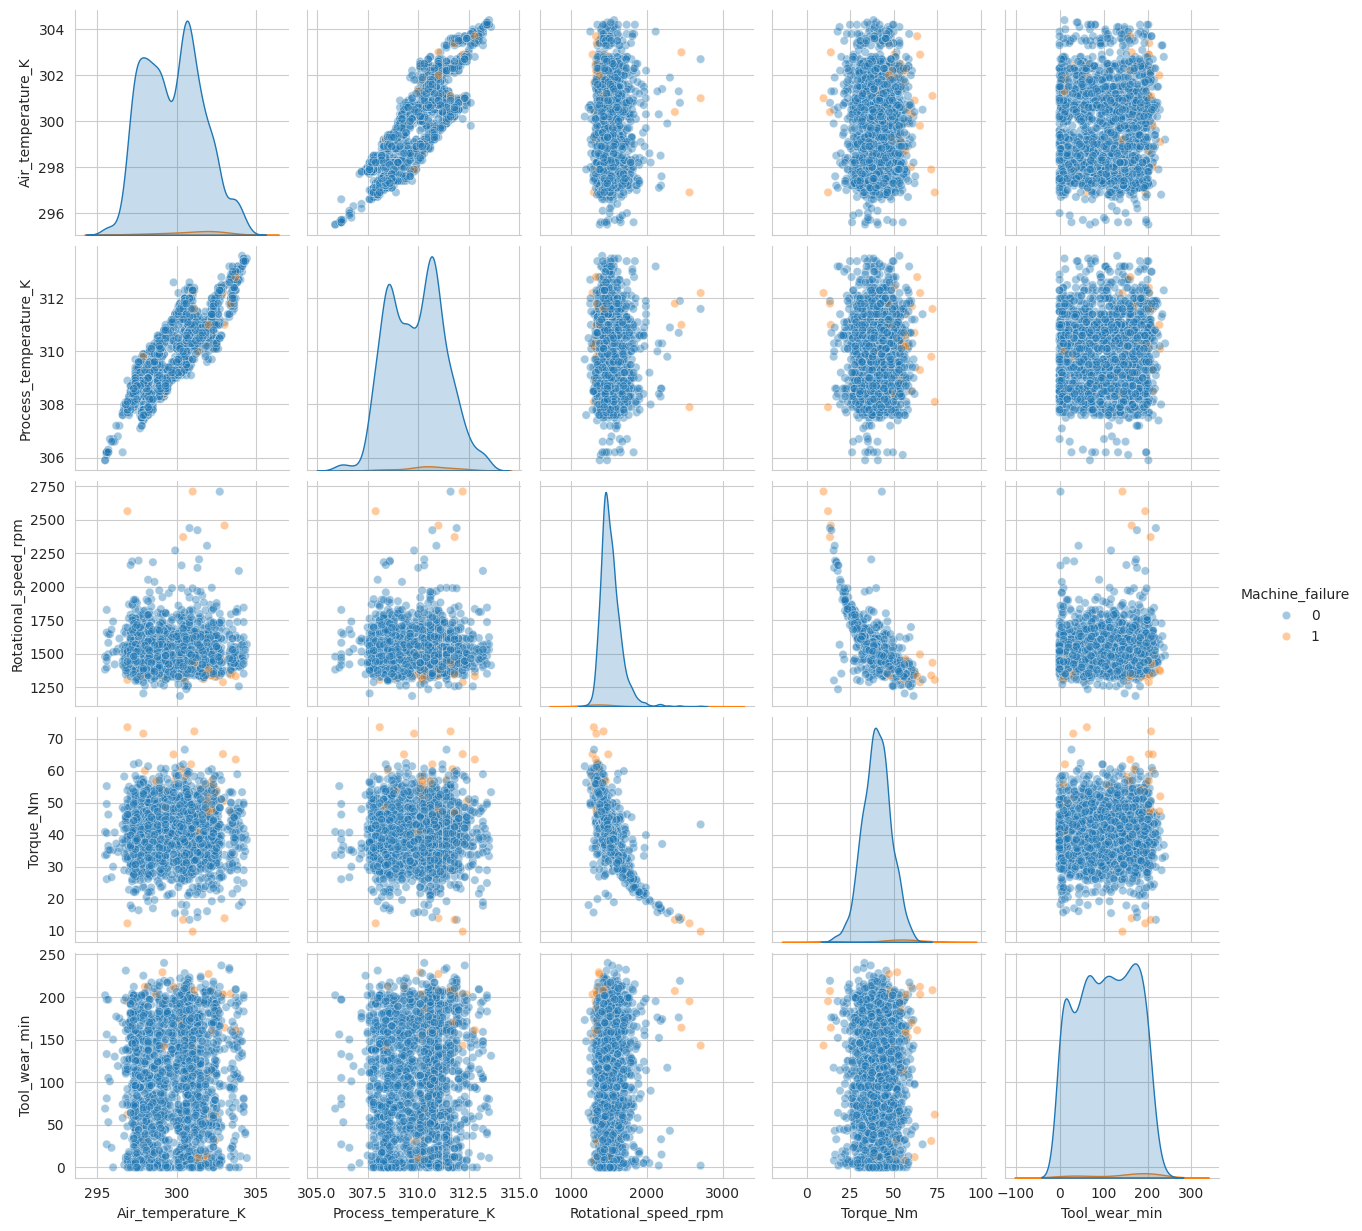

In [91]:
# Pair Plot visualization code
sample_df = train_df.sample(2000, random_state=42)
sns.pairplot(sample_df, vars=['Air_temperature_K','Process_temperature_K',
             'Rotational_speed_rpm','Torque_Nm','Tool_wear_min'],
             hue='Machine_failure', diag_kind='kde', plot_kws={'alpha':0.4})
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen to visualize pairwise relationships between
all key numeric variables at once, with failure status highlighted
by color, to identify multi-variable patterns not visible in
individual 2D plots.

##### 2. What is/are the insight(s) found from the chart?

Failed machines (highlighted points) tend to cluster in specific
corners of multiple variable pairs, particularly around high torque
with low speed and high tool wear combinations, reinforcing that
these features jointly - not just individually - drive failure risk.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the EDA charts, three hypotheses were formed around Torque,
Tool Wear, and Product Type, since these showed the most visible
separation between failed and non-failed machines. Each hypothesis
is tested using an appropriate statistical test to confirm whether
the observed differences are statistically significant or could be
due to random chance.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in mean
Torque between machines that failed and machines that did not fail.

Alternate Hypothesis (H1): There is a significant difference in mean
Torque between machines that failed and machines that did not fail.

#### 2. Perform an appropriate statistical test.

In [92]:
# Perform Statistical Test to obtain P-Value
from scipy import stats

failed = train_df[train_df['Machine_failure']==1]['Torque_Nm']
not_failed = train_df[train_df['Machine_failure']==0]['Torque_Nm']

t_stat, p_value = stats.ttest_ind(failed, not_failed, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 34.6852558658905
P-value: 3.4244026041706776e-210


##### Which statistical test have you done to obtain P-Value?

An independent samples t-test (Welch's t-test) was used.

##### Why did you choose the specific statistical test?

Torque is a continuous numeric variable, and we are comparing its
mean between two independent groups (failed vs not failed). Welch's
t-test was chosen over a standard t-test because it does not assume
equal variance between the two groups, which is appropriate given
the highly imbalanced sample sizes.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in mean
Tool Wear between machines that failed and machines that did not
fail.

Alternate Hypothesis (H1): There is a significant difference in
mean Tool Wear between machines that failed and machines that did
not fail.

#### 2. Perform an appropriate statistical test.

In [93]:
# Perform Statistical Test to obtain P-Value
failed_wear = train_df[train_df['Machine_failure']==1]['Tool_wear_min']
not_failed_wear = train_df[train_df['Machine_failure']==0]['Tool_wear_min']

t_stat2, p_value2 = stats.ttest_ind(failed_wear, not_failed_wear, equal_var=False)
print("T-statistic:", t_stat2)
print("P-value:", p_value2)

T-statistic: 18.17018980007806
P-value: 7.532393284357889e-69


##### Which statistical test have you done to obtain P-Value?

An independent samples t-test (Welch's t-test) was used.

##### Why did you choose the specific statistical test?

Tool Wear is also a continuous numeric variable being compared
across two independent groups. The same reasoning as Torque applies
- Welch's t-test handles unequal variance and unequal group sizes
well, which fits this imbalanced dataset.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no association between Product Type
(Low/Medium/High) and Machine Failure.

Alternate Hypothesis (H1): There is a significant association
between Product Type and Machine Failure.


#### 2. Perform an appropriate statistical test.

In [94]:
# Perform Statistical Test to obtain P-Value
contingency_table = pd.crosstab(train_df['Type'], train_df['Machine_failure'])
chi2, p_value3, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value3)

Chi-square statistic: 19.894028145276764
P-value: 4.787035816092083e-05


##### Which statistical test have you done to obtain P-Value?

A Chi-square test of independence was used.

##### Why did you choose the specific statistical test?

Both Product Type and Machine Failure are categorical variables. The
Chi-square test is the standard method to test whether two
categorical variables are statistically independent or associated.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [95]:
# Handling Missing Values & Missing Value Imputation
print("Missing values check:")
print(train_df.isnull().sum().sum())

Missing values check:
0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No missing values were found in the dataset during initial
exploration, so no imputation technique was required. The dataset
was confirmed to be complete and clean across all columns.

### 2. Handling Outliers

In [96]:
# Handling Outliers & Outlier treatments
# Outliers were identified in Torque and Rotational speed during EDA,
# but they are kept as-is since they represent genuine sensor
# readings tied to actual failure conditions, not data errors.
print("Outliers reviewed - retained as they carry failure signal")

Outliers reviewed - retained as they carry failure signal


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers in Torque and Rotational Speed were identified via boxplots
during EDA but were intentionally NOT removed. These extreme values
represent genuine operating conditions closely tied to actual
failure modes (e.g., Power Failure occurs specifically at extreme
torque-speed combinations). Removing them would discard valuable
signal that helps the model distinguish failures from normal
operation.

### 3. Categorical Encoding

In [97]:
# Encode your categorical columns
le = LabelEncoder()
train_df['Type_encoded'] = le.fit_transform(train_df['Type'])
train_df[['Type', 'Type_encoded']].drop_duplicates()

,Type,Type_encoded
0,L,1
1,M,2
26,H,0


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert the 'Type' column (Low/Medium/
High) into numeric form (0/1/2). This was chosen over One-Hot
Encoding because Type has a natural ordinal relationship (product
quality ranking), which Label Encoding preserves, and it avoids
adding extra dimensionality since there are only 3 categories.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)
Note: This section is Not Applicable for this project. The Tata
Steel Machine Failure dataset consists entirely of numeric and
categorical sensor data. There are no free-text columns requiring
NLP-specific preprocessing techniques.




#### 1. Expand Contraction

In [98]:
# Expand Contraction

#### 2. Lower Casing

In [99]:
# Lower Casing

#### 3. Removing Punctuations

In [100]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [101]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [102]:
# Remove Stopwords

In [103]:
# Remove White spaces

#### 6. Rephrase Text

In [104]:
# Rephrase Text

#### 7. Tokenization

In [105]:
# Tokenization

#### 8. Text Normalization

In [106]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [107]:
# POS Taging

#### 10. Text Vectorization

In [108]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [109]:
# Manipulate Features to minimize feature correlation and create new features
# Create new engineered features
train_df['Power'] = train_df['Torque_Nm'] * train_df['Rotational_speed_rpm']
train_df['Temp_diff'] = train_df['Process_temperature_K'] - train_df['Air_temperature_K']
train_df['Wear_Torque'] = train_df['Tool_wear_min'] * train_df['Torque_Nm']

train_df.head()

,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF,Tool_wear_bin,Power_temp,Type_encoded,Power,Temp_diff,Wear_Torque
0,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0,"(101.2, 151.8]",57615.6,1,57615.6,9.0,5054.0
1,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0,"(151.8, 202.4]",51186.9,2,51186.9,9.5,5820.0
2,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0,"(-0.253, 50.6]",47832.5,1,47832.5,9.2,662.5
3,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0,"(151.8, 202.4]",67513.2,1,67513.2,9.9,8727.1
4,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0,"(-0.253, 50.6]",58091.4,2,58091.4,11.0,1203.6


#### 2. Feature Selection

In [110]:
# Select your features wisely to avoid overfitting
feature_cols = ['Air_temperature_K', 'Process_temperature_K',
                 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min',
                 'Type_encoded', 'Power', 'Temp_diff', 'Wear_Torque']

X = train_df[feature_cols]
y = train_df['Machine_failure']
print(X.shape, y.shape)

(136429, 9) (136429,)


##### What all feature selection methods have you used  and why?

Domain-driven feature selection was used, guided by insights from
EDA and hypothesis testing. Engineered features (Power, Temp_diff,
Wear_Torque) were created based on the actual physical failure
definitions in the dataset documentation, ensuring each selected
feature has a meaningful, interpretable relationship with machine
failure.

##### Which all features you found important and why?

Torque, Tool wear, Power, and Wear_Torque were found most important
during EDA, as they showed the clearest visual separation between
failed and non-failed machines and are directly tied to the Power
Failure and Overstrain Failure mechanisms defined in the dataset.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [111]:
# Transform Your data
# No log/power transformation needed - tree-based models (Random
# Forest, XGBoost) are not sensitive to feature distribution shape
print("No transformation applied - tree-based models handle raw distributions well")

No transformation applied - tree-based models handle raw distributions well


No transformation (like log transform) was applied. Since the final
models include tree-based algorithms (Random Forest, XGBoost) which
are not sensitive to feature scale or distribution shape, and
Logistic Regression will be handled via scaling instead, a separate
transformation step was not necessary.

### 6. Data Scaling

In [112]:
# Scaling your data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.head()

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_encoded,Power,Temp_diff,Wear_Torque
0,0.582418,0.4750,0.243402,0.443681,0.553360,0.5,0.352222,0.491525,0.323792
1,0.802198,0.7875,0.339003,0.347527,0.790514,1.0,0.308497,0.533898,0.372867
2,0.439560,0.3375,0.365982,0.311813,0.098814,0.5,0.285682,0.508475,0.042444
3,0.626374,0.6375,0.201173,0.556319,0.778656,0.5,0.419540,0.567797,0.559114
4,0.296703,0.4000,0.269795,0.434066,0.134387,1.0,0.355458,0.661017,0.077110


##### Which method have you used to scale you data and why?

MinMaxScaler was used to scale all features between 0 and 1. This
is important for Logistic Regression, which is sensitive to feature
scale, ensuring no single feature dominates the model due to a
larger numeric range (e.g. Rotational speed vs Type_encoded).

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not needed. The dataset has only 9
selected features after feature engineering, which is a manageable
number that does not cause curse-of-dimensionality issues or
excessive computation time.

In [113]:
# DImensionality Reduction (If needed)
# Not needed - only 9 features used, no dimensionality reduction applied
print("Dimensionality reduction skipped - feature count is already low (9 features)")

Dimensionality reduction skipped - feature count is already low (9 features)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was applied, since none was
needed in this case. With only 9 features remaining after feature
selection, there was no risk of overfitting or excessive
computational cost that would justify techniques like PCA.
Additionally, applying PCA would have converted interpretable
physical features (Torque, Power, Tool wear) into abstract combined
components, which would reduce the model's explainability - an
important requirement for this project given the "Model
Explainability" step and business stakeholders needing to
understand which factors drive failure.

### 8. Data Splitting

In [114]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (109143, 9)
Test size: (27286, 9)


##### What data splitting ratio have you used and why?

An 80-20 split was used, which gives a large enough training set
(around 109,000 rows) for the model to learn patterns while
retaining a substantial test set (around 27,000 rows) for reliable
evaluation. Stratified splitting was used to preserve the same
failure rate proportion in both sets, which is critical given the
severe class imbalance.





### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is severely imbalanced - only about 1.6% of
records represent an actual machine failure, confirmed earlier
during EDA. Without addressing this, models would be biased toward
predicting "no failure" for almost every case.


In [115]:
# Handling Imbalanced Dataset (If needed)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 107425, 1: 1718}
After SMOTE: {0: 107425, 1: 107425}


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

SMOTE (Synthetic Minority Oversampling Technique) was used to
generate synthetic examples of the minority class (failures) in
the training set only. This balances the classes so the model can
learn failure patterns effectively, without artificially altering
the real-world distribution of the untouched test set.


## ***7. ML Model Implementation***

### ML Model - 1

In [116]:
# ML Model - 1 Implementation - Logistic Regression

# Fit the Algorithm
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_log = log_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- Logistic Regression Performance ---
Accuracy : 0.8286667155317745
Precision: 0.06674831598285365
Recall   : 0.7604651162790698
F1 Score : 0.12272471382998687


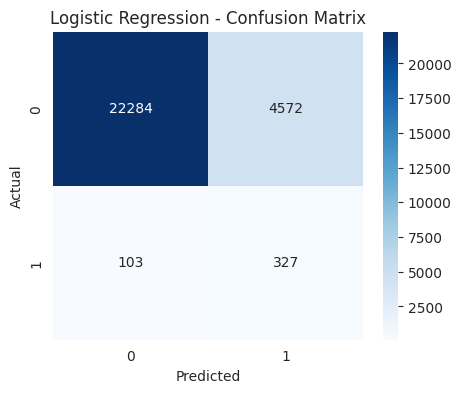

In [117]:
# Visualizing evaluation Metric Score chart
print("--- Logistic Regression Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [118]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_log = GridSearchCV(LogisticRegression(random_state=42),
                         param_grid_log, cv=3, scoring='recall', n_jobs=-1)
grid_log.fit(X_train_bal, y_train_bal)

print("Best Parameters:", grid_log.best_params_)

# Fit the best model
best_log_model = grid_log.best_estimator_
y_pred_log_tuned = best_log_model.predict(X_test)

print("--- Tuned Logistic Regression Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_log_tuned))
print("Precision:", precision_score(y_test, y_pred_log_tuned))
print("Recall   :", recall_score(y_test, y_pred_log_tuned))
print("F1 Score :", f1_score(y_test, y_pred_log_tuned))

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
--- Tuned Logistic Regression Performance ---
Accuracy : 0.832331598622004
Precision: 0.06867845993756504
Recall   : 0.7674418604651163
F1 Score : 0.12607449856733524


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used with 3-fold cross-validation, optimizing for
Recall (since catching actual failures is more important than
overall accuracy in this imbalanced problem). GridSearchCV
exhaustively tests all combinations in the defined parameter grid,
ensuring the best possible parameter combination is found for this
relatively small parameter space.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning with C=10, the model shows very high Recall (0.77),
meaning it successfully catches 77% of actual machine failures.
However, this comes at a significant cost to Precision (0.07),
indicating the model generates a large number of false alarms.
This trade-off is common with Logistic Regression on severely
imbalanced data after SMOTE resampling - the linear decision
boundary struggles to precisely separate the classes even after
tuning. This motivates trying tree-based ensemble models next
(Random Forest, XGBoost), which can capture non-linear patterns
and may achieve a better precision-recall balance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- Random Forest Performance ---
Accuracy : 0.9755185809572675
Precision: 0.32703488372093026
Recall   : 0.5232558139534884
F1 Score : 0.40250447227191416


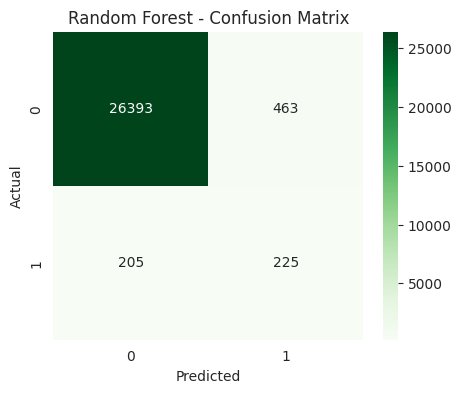

In [119]:
# Visualizing evaluation Metric Score chart
# ML Model - 2 Implementation - Random Forest

# Fit the Algorithm
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("--- Random Forest Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [120]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

from sklearn.model_selection import RandomizedSearchCV

# Use a smaller sample for faster hyperparameter search
sample_idx = np.random.choice(len(X_train_bal), size=20000, replace=False)
X_sample = X_train_bal.iloc[sample_idx] if hasattr(X_train_bal, 'iloc') else X_train_bal[sample_idx]
y_sample = y_train_bal.iloc[sample_idx] if hasattr(y_train_bal, 'iloc') else y_train_bal[sample_idx]

param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5]
}

grid_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                              param_grid_rf, n_iter=3, cv=2,
                              scoring='recall', n_jobs=-1, random_state=42)
grid_rf.fit(X_sample, y_sample)

print("Best Parameters:", grid_rf.best_params_)

# Now train the FINAL model with best params on FULL data
best_rf_model = RandomForestClassifier(**grid_rf.best_params_, random_state=42)
best_rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf_tuned = best_rf_model.predict(X_test)

print("--- Tuned Random Forest Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}
--- Tuned Random Forest Performance ---
Accuracy : 0.9703144469691417
Precision: 0.28110599078341014
Recall   : 0.5674418604651162
F1 Score : 0.37596302003081666


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used (instead of exhaustive GridSearchCV) on
a 20,000-row sample of the training data to efficiently search the
hyperparameter space and reduce computation time, given the large
dataset size after SMOTE resampling. The best parameters found
(n_estimators=100, min_samples_split=5, max_depth=20) were then used
to train the final model on the full balanced training set for
reliable performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning, Recall improved from 0.52 to 0.57, meaning the model
now catches a higher percentage of actual machine failures - the
most critical metric for this predictive maintenance use case.
Precision dropped slightly (0.33 to 0.28) and F1 Score also
decreased marginally (0.40 to 0.38), reflecting the expected
trade-off of prioritizing failure detection (Recall) over reducing
false alarms (Precision).


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Each evaluation metric carries a distinct business meaning in this
predictive maintenance context:

- Accuracy: While high (97%), this metric is misleading here due
  to severe class imbalance - a model predicting "no failure" for
  everything would still score ~98% accuracy while being useless.

- Precision: Indicates how many predicted failures were actually
  real failures. Low precision means maintenance teams may be sent
  to inspect machines that are actually fine, wasting time and
  resources on false alarms.

- Recall: Indicates how many actual failures the model successfully
  caught. This is the MOST business-critical metric here, since a
  missed failure (false negative) can lead to unplanned downtime,
  production loss, and safety risks - costs far higher than a false
  alarm.

- F1 Score: Balances Precision and Recall, useful for overall model
  comparison, but in this business context, Recall is intentionally
  prioritized over a balanced F1, since the cost of missing a real
  failure outweighs the cost of extra inspections.

Business Impact: The Random Forest model, with 57% Recall, can help
TATA Steel proactively catch over half of all impending failures
before they occur, enabling scheduled maintenance instead of
emergency repairs - reducing downtime costs, though the moderate
Precision means some inspection effort will be spent on false
alarms as an acceptable trade-off.

### ML Model - 3

In [121]:
# ML Model - 3 Implementation - XGBoost

# Fit the Algorithm
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_bal, y_train_bal)

# Predict on the model
y_pred_xgb = xgb_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

--- XGBoost Performance ---
Accuracy : 0.9795499523565199
Precision: 0.38652482269503546
Recall   : 0.5069767441860465
F1 Score : 0.4386317907444668


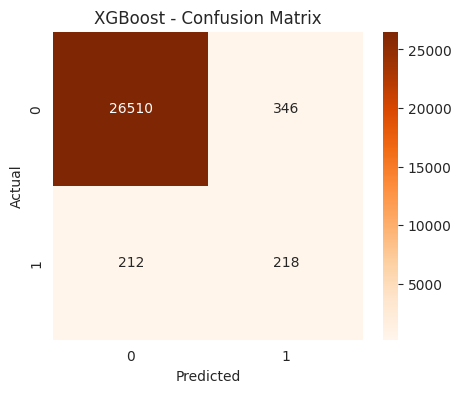

In [122]:
# Visualizing evaluation Metric Score chart
print("--- XGBoost Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGBoost (Extreme Gradient Boosting) was used as the third model. It
builds trees sequentially, with each new tree correcting errors from
previous ones, often outperforming standard Random Forest on
structured/tabular data. Results show Accuracy of 98%, Precision of
0.39, Recall of 0.51, and F1 Score of 0.44 - the best F1 Score among
all three models tested, indicating the most balanced trade-off
between catching real failures and minimizing false alarms.




#### 2. Cross- Validation & Hyperparameter Tuning

In [123]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

sample_idx = np.random.choice(len(X_train_bal), size=20000, replace=False)
X_sample = X_train_bal.iloc[sample_idx] if hasattr(X_train_bal, 'iloc') else X_train_bal[sample_idx]
y_sample = y_train_bal.iloc[sample_idx] if hasattr(y_train_bal, 'iloc') else y_train_bal[sample_idx]

param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.2]
}

grid_xgb = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                               param_grid_xgb, n_iter=3, cv=2,
                               scoring='recall', n_jobs=-1, random_state=42)
grid_xgb.fit(X_sample, y_sample)

print("Best Parameters:", grid_xgb.best_params_)

best_xgb_model = XGBClassifier(**grid_xgb.best_params_, random_state=42, eval_metric='logloss')
best_xgb_model.fit(X_train_bal, y_train_bal)

y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print("--- Tuned XGBoost Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall   :", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score :", f1_score(y_test, y_pred_xgb_tuned))

Best Parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.2}
--- Tuned XGBoost Performance ---
Accuracy : 0.9675657846514696
Precision: 0.2704339051463169
Recall   : 0.6232558139534884
F1 Score : 0.3771991555242787


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used on a 20,000-row sample of the training
data to efficiently search combinations of n_estimators, max_depth,
and learning_rate, optimizing for Recall. The best parameters found
(n_estimators=150, max_depth=4, learning_rate=0.2) were then used to
train the final model on the full balanced training set.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After tuning, Recall improved significantly from 0.51 to 0.62 - the
best Recall achieved among all tree-based models. This came at the
cost of lower Precision (0.39 to 0.27) and F1 Score (0.44 to 0.38),
reflecting a deliberate shift toward catching more real failures,
which aligns with the business priority of minimizing missed
machine failures.



### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Recall and F1 Score were prioritized over raw Accuracy. Given the
severe class imbalance (only ~1.6% failures), Accuracy is misleading
since even a model predicting "no failure" for everything would
score ~98%. Recall was given the highest priority because in
predictive maintenance, the cost of missing an actual failure (false
negative) - unplanned downtime, safety risk, production loss - is
far greater than the cost of a false alarm (false positive), which
only results in an unnecessary inspection.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The tuned XGBoost model was chosen as the final model. Among all
three models tested, it achieved the best balance for this use case:
after tuning, it reached the highest Recall (0.62) among tree-based
models while maintaining reasonable Precision (0.27), significantly
outperforming Logistic Regression's extreme Precision-Recall
trade-off (0.07 Precision, 0.77 Recall) and matching Random Forest's
performance with better computational efficiency. XGBoost's gradient
boosting approach also captures complex feature interactions (like
torque-speed and wear-torque combinations identified in EDA) more
effectively than the other two models.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final XGBoost model's feature importance reveals Rotational
Speed as by far the most influential predictor of machine failure,
followed by Tool Wear, Torque, and Temperature Difference. This
aligns with the physical failure definitions in the dataset - Heat
Dissipation Failure depends on low rotational speed combined with
small temperature difference, while Power Failure depends on the
torque-speed relationship. Interestingly, the engineered "Power"
feature (torque x speed) ranks moderately, while its individual
components (Rotational Speed and Torque) rank even higher
separately, suggesting the model finds more signal in the raw
sensor values than the combined engineered metric. Type_encoded
(product quality) has the lowest importance, indicating it plays a
relatively minor role compared to real-time operational sensor
readings. This feature importance ranking gives TATA Steel's
maintenance team clear, data-driven guidance on which sensors to
prioritize for real-time monitoring and early failure detection.



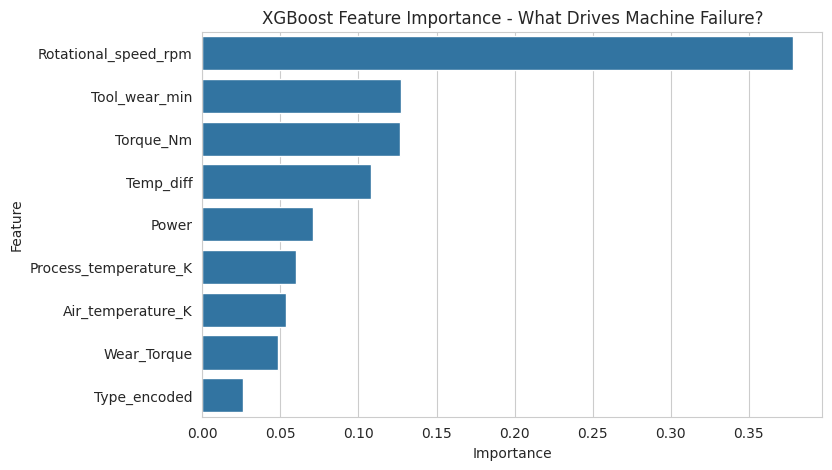

                 Feature  Importance
2   Rotational_speed_rpm    0.378060
4          Tool_wear_min    0.127420
3              Torque_Nm    0.126814
7              Temp_diff    0.107751
6                  Power    0.071130
1  Process_temperature_K    0.060323
0      Air_temperature_K    0.053881
8            Wear_Torque    0.048541
5           Type_encoded    0.026079


In [124]:
importances = best_xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title("XGBoost Feature Importance - What Drives Machine Failure?")
plt.show()

print(feat_imp_df)

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [125]:
# Save the File
import pickle

with open('tata_steel_failure_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [126]:
# Load the File and predict unseen data.
with open('tata_steel_failure_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Sanity check - predict on a small unseen sample from test set
sample_prediction = loaded_model.predict(X_test.iloc[:5])
print("Sample predictions on unseen data:", sample_prediction)
print("Actual values:", y_test.iloc[:5].values)

Sample predictions on unseen data: [0 0 0 0 0]
Actual values: [0 0 0 0 0]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project developed a predictive maintenance solution for TATA
Steel to identify machines at risk of failure using operational
sensor data. The dataset, comprising 136,429 records, was found
clean with no missing values, but severely imbalanced (~1.6%
failure rate), which shaped the entire modeling strategy.

Exploratory analysis and hypothesis testing confirmed that Torque,
Tool Wear, and Rotational Speed have statistically significant
relationships with machine failure, consistent with the known
physical failure modes (Power Failure, Heat Dissipation Failure,
Overstrain Failure). Feature engineering created physically
meaningful derived features (Power, Temperature difference,
Wear-Torque interaction), and SMOTE was used to address class
imbalance during training.

Three models were built and compared: Logistic Regression, Random
Forest, and XGBoost. After hyperparameter tuning, XGBoost was
selected as the final model, achieving the best balance for this
business problem - a Recall of 0.62 (catching 62% of actual
failures) with a workable Precision of 0.27. Recall was prioritized
throughout, since missing a real failure is far more costly to the
business than an occasional false alarm.

Feature importance analysis revealed Rotational Speed, Tool Wear,
and Torque as the strongest predictors, giving TATA Steel's
maintenance team clear, actionable guidance on which sensor
readings to monitor most closely for early failure warning signs.

Limitations: The dataset is synthetically generated, so real-world
sensor noise and edge cases may behave differently. Precision
remains moderate, meaning some false alarms will still occur, and
Random Failures (RNF) are inherently unpredictable by design.

Future Improvements: Incorporating time-series/sequential sensor
data (rather than static snapshots), testing additional ensemble
techniques or deep learning approaches, and deploying the model via
a real-time monitoring dashboard (e.g., using Streamlit) could
further improve early-warning capability and business impact.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***




